## Dependencias

In [8]:
# Data Wrangling
import os
# import zipfile
import numpy as np
import pandas as pd

import shutil
import random
from collections import Counter

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Modeling
import tensorflow as tf
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization, Activation
from sklearn.utils.class_weight import compute_class_weight

# Data Visualization
import cufflinks as cf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, ImageDraw, ImageFont

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Configuración del notebook
cf.go_offline()
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.FATAL)

## Carpetas de Train y Val

In [ ]:
ruta_train = r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Prácticas\Práctica II\CNN_Simpsons\simpsons_dataset\train"

ruta_val = r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Prácticas\Práctica II\CNN_Simpsons\simpsons_dataset\val"

## Mosaico

In [ ]:
from mosaico_simpons import obtener_imagenes_simpsons, crear_mosaico_simpsons

imagenes = obtener_imagenes_simpsons(ruta_train, n_por_clase=4)

mosaico = crear_mosaico_simpsons(imagenes, columnas=6)

mosaico.show()

## Generadores

In [9]:
# Revisamos el tamaño de las imágenes

for clase in os.listdir(ruta_train):
    ruta_clase = os.path.join(ruta_train, clase)
    
    if os.path.isdir(ruta_clase):
        img_path = os.path.join(ruta_clase, os.listdir(ruta_clase)[0])
        
        with Image.open(img_path) as img:
            print(f"Clase: {clase} -> Tamaño: {img.size}")
        

Clase: homer_simpson -> Tamaño: (150, 150)
Clase: ned_flanders -> Tamaño: (150, 150)
Clase: moe_szyslak -> Tamaño: (150, 150)
Clase: lisa_simpson -> Tamaño: (150, 150)
Clase: bart_simpson -> Tamaño: (150, 150)
Clase: marge_simpson -> Tamaño: (150, 150)
Clase: krusty_the_clown -> Tamaño: (150, 150)
Clase: principal_skinner -> Tamaño: (150, 150)
Clase: charles_montgomery_burns -> Tamaño: (150, 150)
Clase: milhouse_van_houten -> Tamaño: (150, 150)
Clase: chief_wiggum -> Tamaño: (150, 150)
Clase: abraham_grampa_simpson -> Tamaño: (150, 150)
Clase: sideshow_bob -> Tamaño: (150, 150)
Clase: apu_nahasapeemapetilon -> Tamaño: (150, 150)
Clase: kent_brockman -> Tamaño: (150, 150)
Clase: comic_book_guy -> Tamaño: (150, 150)
Clase: edna_krabappel -> Tamaño: (150, 150)
Clase: nelson_muntz -> Tamaño: (150, 150)


In [ ]:
target_size = (150,150)

In [ ]:
# Parámetros
BATCH_SIZE = 32

# Generador de entrenamiento 
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Generador de validación (SIN augmentación)
val_datagen = ImageDataGenerator(
    rescale=1./255
)

# Flow desde carpetas
train_generator = train_datagen.flow_from_directory(
    ruta_train,
    target_size=target_size,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    ruta_val,
    target_size=target_size,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 15185 images belonging to 18 classes.
Found 3807 images belonging to 18 classes.


Con el `class_mode = 'categorical'` se designa automáticamente el target, como veremos en la siguiente celda.

In [11]:
X_batch, y_batch = next(train_generator)
print(f'Los índices de las clases son\n {train_generator.class_indices}')
print(f'\nEl target de la primera fila es:{y_batch[0]}')

Los índices de las clases son
 {'abraham_grampa_simpson': 0, 'apu_nahasapeemapetilon': 1, 'bart_simpson': 2, 'charles_montgomery_burns': 3, 'chief_wiggum': 4, 'comic_book_guy': 5, 'edna_krabappel': 6, 'homer_simpson': 7, 'kent_brockman': 8, 'krusty_the_clown': 9, 'lisa_simpson': 10, 'marge_simpson': 11, 'milhouse_van_houten': 12, 'moe_szyslak': 13, 'ned_flanders': 14, 'nelson_muntz': 15, 'principal_skinner': 16, 'sideshow_bob': 17}

El target de la primera fila es:[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


## Modelado

In [12]:
model = Sequential()

# 🔹 Bloque 1
model.add(Conv2D(32, (3,3), padding='same', input_shape=(150,150,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(2,2))

# 🔹 Bloque 2
model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(2,2))

# 🔹 Bloque 3
model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(2,2))

# 🔹 Clasificador
model.add(Flatten())

model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(train_generator.num_classes, activation='softmax'))

model.summary()

c:\Users\azayas\Diplomado\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,405,522 (20.62 MB)

 Trainable params: 5,404,818 (20.62 MB)

 Non-trainable params: 704 (2.75 KB)

## Parámetros de Entrenamiento

In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
# Call backs

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',   # mejor que accuracy
    patience=10,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'models/model_simpsons_{val_accuracy:.3}.keras',
    save_best_only=True,
    save_weights_only=False,
    monitor='val_accuracy'
)

classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

In [15]:
# Entrenamiento del modelo

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stopping, checkpoint],
    class_weight=class_weights
)

c:\Users\azayas\Diplomado\myenv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 158s 327ms/step - accuracy: 0.3826 - loss: 2.0245 - val_accuracy: 0.5085 - val_loss: 1.6329
Epoch 2/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 184s 388ms/step - accuracy: 0.5275 - loss: 1.4994 - val_accuracy: 0.6388 - val_loss: 1.2299
Epoch 3/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 193s 407ms/step - accuracy: 0.5765 - loss: 1.3395 - val_accuracy: 0.7092 - val_loss: 1.0049
Epoch 4/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 188s 396ms/step - accuracy: 0.6098 - loss: 1.2211 - val_accuracy: 0.7053 - val_loss: 0.9986
Epoch 5/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 196s 412ms/step - accuracy: 0.6299 - loss: 1.1412 - val_accuracy: 0.7329 - val_loss: 0.9305
Epoch 6/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 194s 405ms/step - accuracy: 0.6562 - loss: 1.0627 - val_accuracy: 0.7591 - val_loss: 0.8542
Epoch 7/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 190s 400ms/step - accuracy: 0.6724 - loss: 1.0096 - val_accuracy: 0.7449 - val_loss: 0.8675
Epoch 8/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 191s 403ms/step - accuracy: 0.6827 -

## Resultados del Entrenamiento

In [35]:
results = pd.DataFrame(history.history)
results.to_clipboard(index=False)

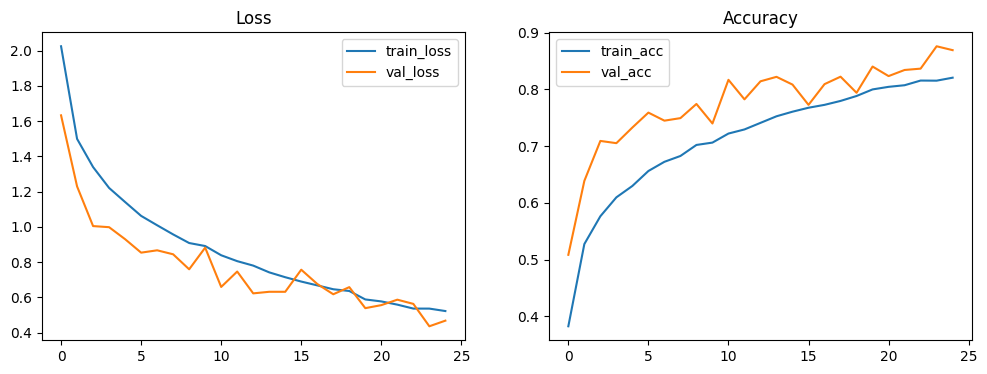

In [17]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(results["loss"], label="train_loss")
plt.plot(results["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(results["accuracy"], label="train_acc")
plt.plot(results["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.show()

## Cargamos el mejor modelo

In [18]:
best_model_name = sorted(os.listdir('./models'))[-1]
best_model_name

'model_simpsons_0.876.keras'

In [19]:
best_model = tf.keras.models.load_model(
    os.path.join(
        './models',
        best_model_name
    )
)

## Evaluación Final

In [20]:
val_generator.reset()

In [21]:
val_loss, val_acc = best_model.evaluate(val_generator)
print(f'Validation loss: {val_loss}')
print(f'Validation accuracy {val_acc}')

119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8760 - loss: 0.4367
Validation loss: 0.4367072880268097
Validation accuracy 0.8760178685188293


In [22]:
# Predicciones sobre validation
pred_probs = best_model.predict(val_generator)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step


In [23]:
pred_classes[:10], true_classes[:10]

(array([0, 0, 0, 0, 7, 0, 0, 7, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32))

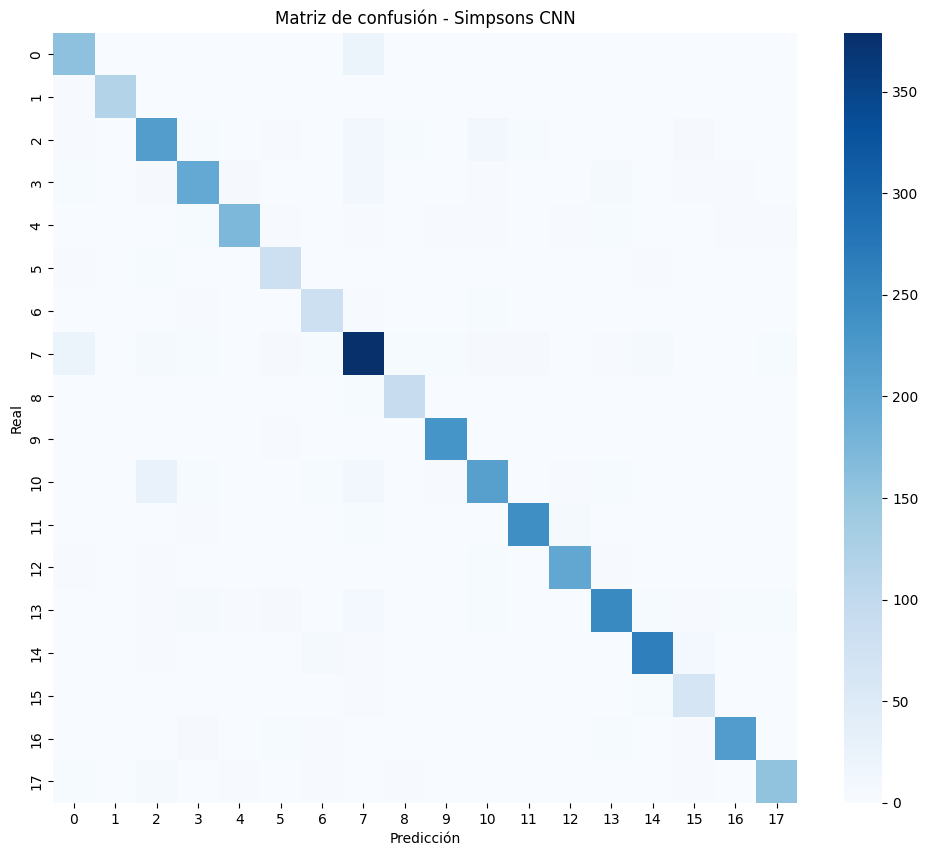

In [24]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Matriz de confusión - Simpsons CNN")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [25]:
print(classification_report(true_classes, pred_classes, target_names=class_labels))

                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.79      0.86      0.83       183
  apu_nahasapeemapetilon       0.94      0.94      0.94       125
            bart_simpson       0.79      0.81      0.80       269
charles_montgomery_burns       0.85      0.83      0.84       239
            chief_wiggum       0.93      0.87      0.90       198
          comic_book_guy       0.78      0.85      0.82        94
          edna_krabappel       0.75      0.88      0.81        92
           homer_simpson       0.82      0.84      0.83       450
           kent_brockman       0.86      0.91      0.88       100
        krusty_the_clown       0.96      0.95      0.96       242
            lisa_simpson       0.86      0.79      0.82       271
           marge_simpson       0.95      0.93      0.94       259
     milhouse_van_houten       0.94      0.93      0.93       216
             moe_szyslak       0.92      0.85      0.88       291
         

## Prediciendo una nueva imágen

In [26]:
# Prediciendo una nueva imagen
index_to_class = {v: k for k, v in train_generator.class_indices.items()}
index_to_class

{0: 'abraham_grampa_simpson',
 1: 'apu_nahasapeemapetilon',
 2: 'bart_simpson',
 3: 'charles_montgomery_burns',
 4: 'chief_wiggum',
 5: 'comic_book_guy',
 6: 'edna_krabappel',
 7: 'homer_simpson',
 8: 'kent_brockman',
 9: 'krusty_the_clown',
 10: 'lisa_simpson',
 11: 'marge_simpson',
 12: 'milhouse_van_houten',
 13: 'moe_szyslak',
 14: 'ned_flanders',
 15: 'nelson_muntz',
 16: 'principal_skinner',
 17: 'sideshow_bob'}

In [34]:
# Imágenes erradas: chief_wiggum_pic_0487.jpg,


img_path = r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Prácticas\Práctica II\simpsons_dataset\val\chief_wiggum\chief_wiggum_pic_0785.jpg"

img = load_img(img_path, target_size=target_size)

img_array = img_to_array(img)

# Normalización
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

class_indices = train_generator.class_indices

idx_to_class = {v: k for k,v in class_indices.items()}

pred_class = np.argmax(pred)
personaje = idx_to_class[pred_class]

print("Predicción:", personaje)

confidence = np.max(pred)

print(f'Personaje: {personaje} ({confidence:.2%})')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicción: chief_wiggum
Personaje: chief_wiggum (53.90%)


## Lista de Personajes no en train ni val

In [58]:
personajes_train = []

for i in os.listdir(train_dir):
    for j in os.listdir(os.path.join(train_dir, i)):
        personajes_train.append(j)

In [59]:
personajes_train = list(set(personajes_train))

In [63]:
personajes_val = []

for i in os.listdir(val_dir):
    for j in os.listdir(os.path.join(val_dir, i)):
        personajes_val.append(j)
        
personajes_val = list(set(personajes_val))

In [64]:
personajes_train_val = personajes_train + personajes_val

In [67]:
test_dir = r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Prácticas\Práctica II\simpsons\simpsons"

personajes_test = []

for i in os.listdir(test_dir):
        personajes_test.append(j)
        
personajes_test = list(set(personajes_test))